# K-Nearest Neighbors (From Scratch)

In this notebook, we implement the K-Nearest Neighbors (KNN) algorithm using only NumPy.

KNN is a non-parametric, instance-based learning method that predicts the label of a sample based on the majority label of its nearest neighbors.

We evaluate it on a real-world census income dataset.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rice_ml import train_test_split, StandardScaler, LabelEncoder

sns.set_theme()

## Dataset: Adult Income

This dataset contains demographic information such as age, education, occupation, and hours worked per week.

The goal is to predict whether a person earns more than $50K per year.

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age", "workclass", "fnlwgt", "education",
    "education-num", "marital-status", "occupation",
    "relationship", "race", "sex", "capital-gain",
    "capital-loss", "hours-per-week", "native-country",
    "income"
]

df = pd.read_csv(url, header=None, names=columns, na_values=" ?", skipinitialspace=True)
# Keep results reproducible
df = df.sample(n=2000, random_state=42).reset_index(drop=True)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,27,Private,160178,Some-college,10,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,38,United-States,<=50K
1,45,State-gov,50567,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
2,29,Private,185908,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Black,Male,0,0,55,United-States,>50K
3,30,Private,190040,Bachelors,13,Never-married,Machine-op-inspct,Not-in-family,White,Female,0,0,40,United-States,<=50K
4,29,Self-emp-not-inc,189346,Some-college,10,Divorced,Craft-repair,Not-in-family,White,Male,2202,0,50,United-States,<=50K


We must preprocess categorical variables since KNN relies on distance computations.

In [4]:
# Drop missing values
df = df.dropna()

# Encode target
df["income"] = df["income"].apply(lambda x: 1 if x == ">50K" else 0)

# Encode categorical features
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

df.head()

/var/folders/vl/g_jc51hx0r7f1gmg0qn5cbhc0000gn/T/ipykernel_29346/3646429407.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,27,3,160178,15,10,0,1,1,4,0,0,0,38,34,0
1,45,6,50567,11,9,1,4,5,4,0,0,0,40,34,0
2,29,3,185908,9,13,1,4,0,2,1,0,0,55,34,1
3,30,3,190040,9,13,3,7,1,4,0,0,0,40,34,0
4,29,5,189346,15,10,0,3,1,4,1,2202,0,50,34,0


KNN is distance-based, so feature scaling is essential.

In [5]:
X = df.drop("income", axis=1).values
y = df["income"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
# Train KNN model
from rice_ml import KNN

model = KNN(k=7)
model.train(X_train, y_train)

Predictions and prediction accuracy

In [7]:
y_pred = model.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {accuracy:.2%}")

Test Accuracy: 83.29%


# Error Analysis

In [8]:
error = model.classification_error(X_test, y_test)
print(f"Classification Error: {error:.2%}")

Classification Error: 16.71%


# Effect of Choosing Different Ks

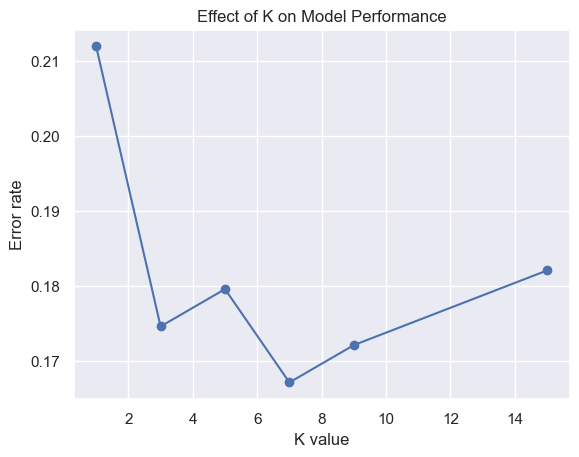

In [9]:
k_values = [1, 3, 5, 7, 9, 15]
errors = []

for k in k_values:
    model = KNN(k=k)
    model.train(X_train, y_train)
    errors.append(model.classification_error(X_test, y_test))

plt.plot(k_values, errors, marker='o')
plt.xlabel("K value")
plt.ylabel("Error rate")
plt.title("Effect of K on Model Performance")
plt.show()

# Decision Boundary (2D Projection)

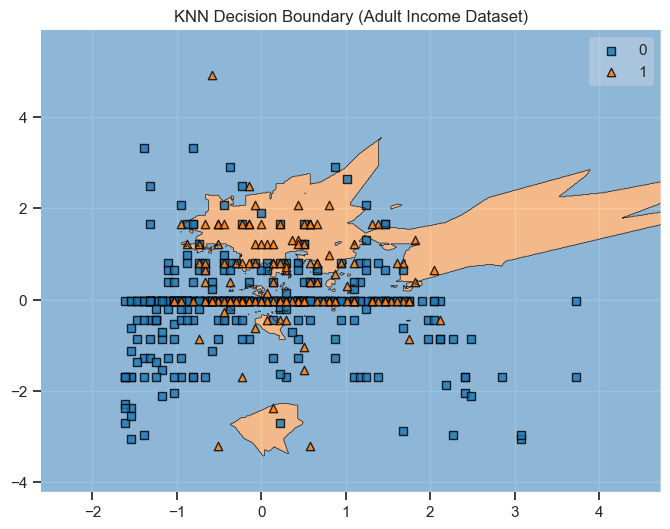

In [10]:
from mlxtend.plotting import plot_decision_regions

# pick two meaningful features
X_vis = X_scaled[:, [0, 12]]  # age vs hours-per-week
X_vis_small = X_vis[:500]

y_small = y[:500]
model_vis = KNN(k=7)
model_vis.train(X_vis_small, y_small)

plt.figure(figsize=(8,6))
plot_decision_regions(X_vis_small, y_small, clf=model_vis)
plt.title("KNN Decision Boundary (Adult Income Dataset)")
plt.show()

### Key Observations

- Dataset is highly non-linear → ideal for KNN
- Feature scaling significantly improves performance
- Class imbalance affects error sensitivity
- KNN performs well without explicit training
- Performance depends heavily on choice of K

### Conclusion

KNN is effective for structured demographic data where similarity in feature space correlates with income levels, even when relationships are non-linear.